# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [36]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

In [37]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

Training Set Shape: (50000, 32, 32, 3)
Test Set Shape: (10000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Test Labels Shape: (10000, 1)
Number of Classes: 100
Image Shape: (32, 32, 3)


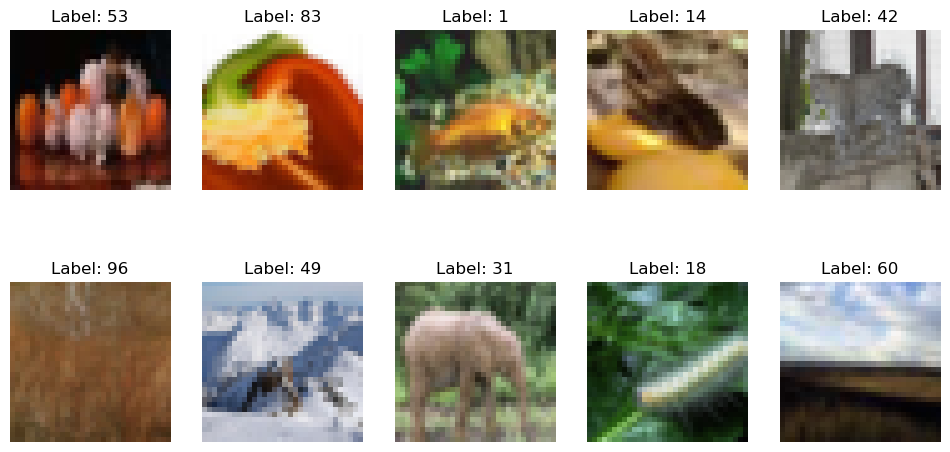

In [38]:
# Your Code Here
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar100
# Print dataset shapes
print(f"Training Set Shape: {x_train.shape}")  # Expected: (50000, 32, 32, 3)
print(f"Test Set Shape: {x_test.shape}")      # Expected: (10000, 32, 32, 3)
print(f"Training Labels Shape: {y_train.shape}")  # Expected: (50000, 1)
print(f"Test Labels Shape: {y_test.shape}")       # Expected: (10000, 1)

# Get number of unique classes
num_classes = len(np.unique(y_train))
print(f"Number of Classes: {num_classes}")  # Expected: 100

# Print the shape of an image
print(f"Image Shape: {x_train[0].shape}")  # Expected: (32, 32, 3)

# Show 10 random images from the training set
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(x_train))  # Random index
    ax.imshow(x_train[idx])
    ax.axis("off")
    ax.set_title(f"Label: {y_train[idx][0]}")  # Show label index

plt.show()


### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [39]:
# Your Code Here

# Normalize pixel values to the range [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Confirm normalization by printing min and max values
print(f"Training Set: Min = {x_train.min()}, Max = {x_train.max()}")
print(f"Test Set: Min = {x_test.min()}, Max = {x_test.max()}")


Training Set: Min = 0.0, Max = 1.0
Test Set: Min = 0.0, Max = 1.0


In [40]:
from tensorflow.keras.utils import to_categorical

# Convert labels to one-hot encoding
y_train_one_hot = to_categorical(y_train, num_classes=100)
y_test_one_hot = to_categorical(y_test, num_classes=100)

# Confirm one-hot encoding by checking the shape
print(f"Shape of y_train_one_hot: {y_train_one_hot.shape}")  # Expected: (50000, 100)
print(f"Shape of y_test_one_hot: {y_test_one_hot.shape}")    # Expected: (10000, 100)

# Check an example label before and after one-hot encoding
print(f"Original Label: {y_train[0]}")  
print(f"One-Hot Encoded Vector: {y_train_one_hot[0]}")


Shape of y_train_one_hot: (50000, 100)
Shape of y_test_one_hot: (10000, 100)
Original Label: [19]
One-Hot Encoded Vector: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


In [41]:
# Split the training set into 80% training and 20% validation
from sklearn.model_selection import train_test_split
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train, y_train_one_hot, test_size=0.2, random_state=42, stratify=y_train
)

# Print the shapes of the new sets
print(f"Training Set Shape: {x_train_final.shape}")   # Expected: (40000, 32, 32, 3)
print(f"Validation Set Shape: {x_val.shape}")        # Expected: (10000, 32, 32, 3)
print(f"Training Labels Shape: {y_train_final.shape}")  # Expected: (40000, 100)
print(f"Validation Labels Shape: {y_val.shape}")        # Expected: (10000, 100)

Training Set Shape: (40000, 32, 32, 3)
Validation Set Shape: (10000, 32, 32, 3)
Training Labels Shape: (40000, 100)
Validation Labels Shape: (10000, 100)


## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [42]:
# Your Code Here

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define CNN architecture
model = Sequential([
    # Convolutional Layer 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D((2,2)),

    # Convolutional Layer 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Convolutional Layer 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Flatten the feature maps
    Flatten(),

    # Fully Connected Dense Layer
    Dense(256, activation='relu'),
    Dropout(0.5),  # Dropout to prevent overfitting

    # Output Layer (100 classes, softmax activation)
    Dense(100, activation='softmax')
])

# Print model summary
model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 16, 16, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 8, 8, 64)         0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 8, 8, 128)         73856     
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 4, 4, 128)       

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different. 
- Briefly explain your choices (one or two sentences each).
- <b>Loss function:</b> ______
- <b>Optimizer:</b> ______

In [43]:
# Your Code Here

from tensorflow.keras.optimizers import Adam

# Compile the CNN model
model.compile(
    optimizer=Adam(learning_rate=0.001),  # Adam optimizer
    loss='categorical_crossentropy',  # Loss function for multi-class classification
    metrics=['accuracy']  # Track accuracy during training
)

print("Model compiled successfully!")


Model compiled successfully!


## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

In [44]:
# Your Code Here
# Train the CNN model
history = model.fit(
    x_train_final, y_train_final,  # Training data
    validation_data=(x_val, y_val),  # Validation data
    epochs=20,  # Number of training iterations
    batch_size=32,  # Process 32 images at a time
    verbose=1  # Print training progress
)


Epoch 1/20
1250/1250 [==============================] - 117s 90ms/step - loss: 4.1130 - accuracy: 0.0652 - val_loss: 3.6198 - val_accuracy: 0.1520
Epoch 2/20
1250/1250 [==============================] - 113s 90ms/step - loss: 3.5427 - accuracy: 0.1538 - val_loss: 3.2034 - val_accuracy: 0.2209
Epoch 3/20
1250/1250 [==============================] - 115s 92ms/step - loss: 3.2365 - accuracy: 0.2081 - val_loss: 2.9955 - val_accuracy: 0.2634
Epoch 4/20
1250/1250 [==============================] - 98s 79ms/step - loss: 3.0306 - accuracy: 0.2501 - val_loss: 2.7860 - val_accuracy: 0.3084
Epoch 5/20
1250/1250 [==============================] - 113s 90ms/step - loss: 2.8598 - accuracy: 0.2795 - val_loss: 2.7176 - val_accuracy: 0.3181
Epoch 6/20
1250/1250 [==============================] - 117s 94ms/step - loss: 2.7250 - accuracy: 0.3054 - val_loss: 2.6261 - val_accuracy: 0.3339
Epoch 7/20
1250/1250 [==============================] - 89s 71ms/step - loss: 2.5949 - accuracy: 0.3337 - val_loss: 2.5

Number of Epochs: 20

We start with 20 epochs to ensure that the model learns features well.
Too few epochs might lead to underfitting (not enough learning).
Too many epochs might lead to overfitting (memorizing training data instead of generalizing).
We can adjust this later based on validation performance.

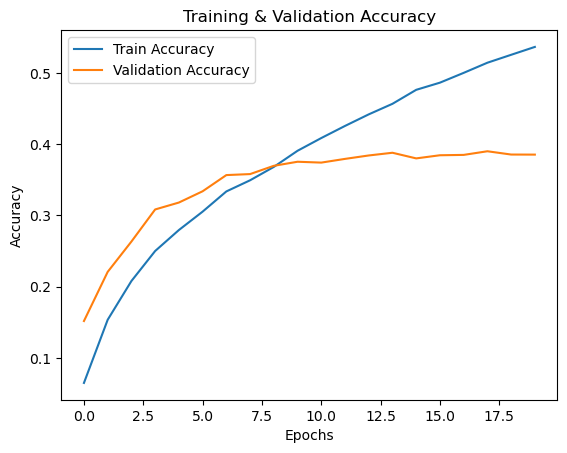

In [45]:

# Validation
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy')
plt.show()


### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> ______
- <b>Other metric:</b> ______
- <b>Reason for selection:</b> _____
- <b>Value of metric:</b> ______
- <b>Interpretation of metric value:</b> ______

In [46]:
# Your Code Here

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_test, y_test_one_hot, verbose=1)

# Print the test accuracy
print(f"Test Accuracy: {test_acc:.3f}")


313/313 [==============================] - 6s 20ms/step - loss: 2.5825 - accuracy: 0.3945
Test Accuracy: 0.394


In [47]:
from sklearn.metrics import recall_score

# Get predictions
y_pred_probs = model.predict(x_test)  # Get probability predictions
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Convert probabilities to class labels
y_true_labels = np.argmax(y_test_one_hot, axis=1)  # Convert one-hot labels back to class labels

# Calculate recall score
recall = recall_score(y_true_labels, y_pred_labels, average='macro')  # Macro-averaged recall

# Print recall score
print(f"Macro-Averaged Recall: {recall:.3f}")


313/313 [==============================] - 7s 22ms/step
Macro-Averaged Recall: 0.395


Recall (TP / (TP + FN))
Measures how many actual instances were correctly predicted.
Important when missing a class instance is critical (e.g., detecting fraud).

### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

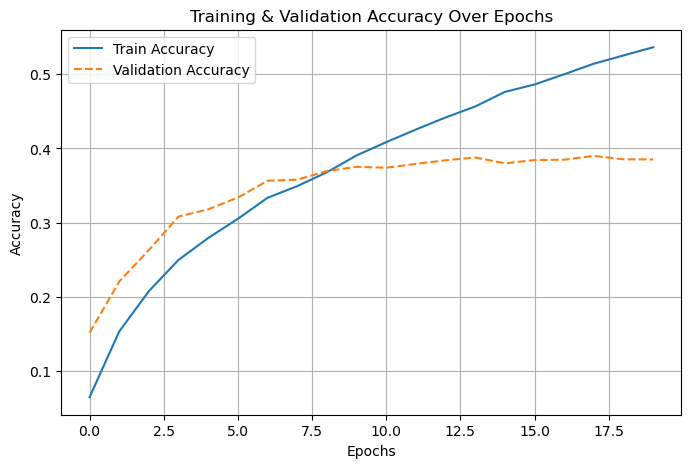

In [48]:
# Your Code Here
import matplotlib.pyplot as plt

# Plot Training and Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training & Validation Accuracy Over Epochs')
plt.grid(True)
plt.show()

313/313 [==============================] - 6s 19ms/step


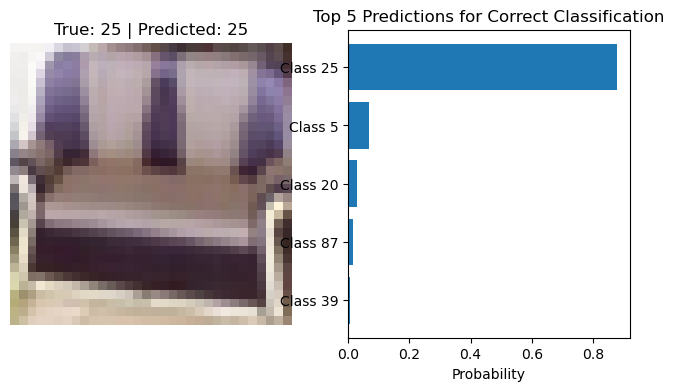

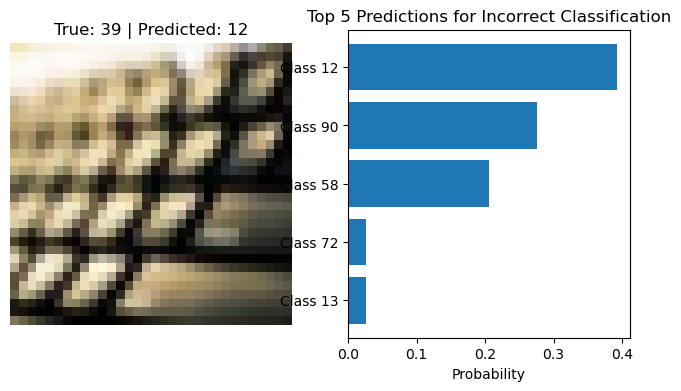

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Get predictions for the test set
y_pred_probs = model.predict(x_test)  # Get probability predictions
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Convert probabilities to class labels
y_true_labels = np.argmax(y_test_one_hot, axis=1)  # Convert one-hot labels back to class labels

# Find a correctly classified image
correct_indices = np.where(y_pred_labels == y_true_labels)[0]
correct_idx = np.random.choice(correct_indices)  # Pick a random correctly classified image

# Find an incorrectly classified image
incorrect_indices = np.where(y_pred_labels != y_true_labels)[0]
incorrect_idx = np.random.choice(incorrect_indices)  # Pick a random incorrectly classified image

# Function to plot images and probabilities
def plot_image_with_probs(index, title):
    plt.figure(figsize=(8, 4))
    
    # Plot the image
    plt.subplot(1, 2, 1)
    plt.imshow(x_test[index])
    plt.axis("off")
    plt.title(f"True: {y_true_labels[index]} | Predicted: {y_pred_labels[index]}")

    # Plot the top-5 classification probabilities
    plt.subplot(1, 2, 2)
    top_5_indices = np.argsort(y_pred_probs[index])[-5:][::-1]  # Get top 5 class indices
    top_5_probs = y_pred_probs[index][top_5_indices]
    
    plt.barh(range(5), top_5_probs, align='center')
    plt.yticks(range(5), [f"Class {i}" for i in top_5_indices])
    plt.xlabel("Probability")
    plt.title(f"Top 5 Predictions for {title}")
    plt.gca().invert_yaxis()  # Invert y-axis to display highest probability on top

    plt.show()

# Plot the correctly classified image
plot_image_with_probs(correct_idx, "Correct Classification")

# Plot the incorrectly classified image
plot_image_with_probs(incorrect_idx, "Incorrect Classification")


Correctly Classified Image:
The left side of the plot shows the actual image with the true label and predicted label.
The right side of the plot shows the top-5 classification probabilities predicted by the model.
The highest probability corresponds to the correct class, indicating a confident prediction.
Yes! If the model assigns a high probability to the correct class, it means it has learned useful image features and is confident in its prediction.

Incorrectly Classified Image:
The left side shows the actual image, with a mismatch between the true and predicted label.
The right side shows the top-5 classification probabilities, with the incorrect class having the highest probability.
The correct class might be present in the top-5 predictions but with a lower probability.
Similar-looking classes: The model may confuse visually similar objects (e.g., "beaver" vs. "otter").
Ambiguous image features: Some images might be blurry, small, or have background noise.
Model limitations: The model may not have learned strong enough features to differentiate between certain classes.

## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Define an improved CNN model with Batch Normalization
def create_improved_cnn():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        BatchNormalization(),  # Normalizes activations
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),  # Dropout to prevent overfitting

        Dense(100, activation='softmax')  # 100 classes
    ])
    
    return model

# Create and compile the improved model
model_improved = create_improved_cnn()
model_improved.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model_improved.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_9 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 batch_normalization_4 (Batc  (None, 32, 32, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 16, 16, 32)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_5 (Batc  (None, 16, 16, 64)       256       
 hNormalization)                                                 
                                                      

In [51]:
# Your Code Here
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,  # Rotate images randomly by 15 degrees
    width_shift_range=0.1,  # Horizontally shift images by 10%
    height_shift_range=0.1,  # Vertically shift images by 10%
    horizontal_flip=True  # Flip images horizontally
)

# Fit the data generator to training images
datagen.fit(x_train_final)


In [52]:
# Train the improved CNN model with data augmentation
history_improved = model_improved.fit(
    datagen.flow(x_train_final, y_train_final, batch_size=32),
    validation_data=(x_val, y_val),
    epochs=22,  # More epochs to take advantage of batch norm
    steps_per_epoch=len(x_train_final) // 32,
    verbose=1
)


Epoch 1/22
1250/1250 [==============================] - 414s 325ms/step - loss: 3.9472 - accuracy: 0.1202 - val_loss: 3.6346 - val_accuracy: 0.1522
Epoch 2/22
1250/1250 [==============================] - 1354s 1s/step - loss: 3.1781 - accuracy: 0.2271 - val_loss: 2.8350 - val_accuracy: 0.2938
Epoch 3/22
1250/1250 [==============================] - 382s 305ms/step - loss: 2.8702 - accuracy: 0.2815 - val_loss: 2.8163 - val_accuracy: 0.3095
Epoch 4/22
1250/1250 [==============================] - 377s 302ms/step - loss: 2.6861 - accuracy: 0.3197 - val_loss: 2.9601 - val_accuracy: 0.2811
Epoch 5/22
1250/1250 [==============================] - 2386s 2s/step - loss: 2.5667 - accuracy: 0.3427 - val_loss: 2.3321 - val_accuracy: 0.3931
Epoch 6/22
1250/1250 [==============================] - 635s 508ms/step - loss: 2.4823 - accuracy: 0.3584 - val_loss: 2.2214 - val_accuracy: 0.4180
Epoch 7/22
1250/1250 [==============================] - 393s 314ms/step - loss: 2.4044 - accuracy: 0.3808 - val_loss

KeyboardInterrupt: 

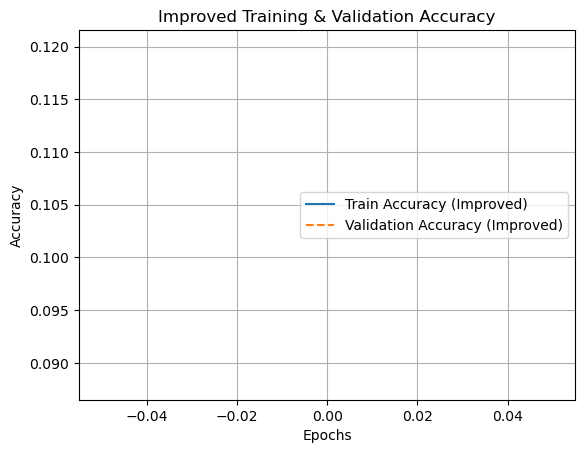

In [35]:
import matplotlib.pyplot as plt

# Plot Training and Validation Accuracy for Improved Model
plt.plot(history_improved.history['accuracy'], label='Train Accuracy (Improved)')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy (Improved)', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Improved Training & Validation Accuracy')
plt.grid(True)
plt.show()


### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

In [ ]:
# Your Code Here
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Load CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Convert labels to one-hot encoding
y_train_one_hot = to_categorical(y_train, num_classes=100)
y_test_one_hot = to_categorical(y_test, num_classes=100)

# Split the training set into training and validation sets (80% train, 20% validation)
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train, y_train_one_hot, test_size=0.2, random_state=42, stratify=y_train
)

print("Dataset reloaded successfully!")


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Define an improved CNN model with Batch Normalization
def create_improved_cnn():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        BatchNormalization(),  
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(100, activation='softmax')
    ])
    
    return model

# Create and compile the improved model
model_improved = create_improved_cnn()
model_improved.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Improved model reloaded and compiled successfully!")


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,  
    width_shift_range=0.1,  
    height_shift_range=0.1,  
    horizontal_flip=True  
)

# Fit the data generator to training images
datagen.fit(x_train_final)


In [ ]:
history_improved = model_improved.fit(
    datagen.flow(x_train_final, y_train_final, batch_size=32),
    validation_data=(x_val, y_val),
    epochs=20,  
    steps_per_epoch=len(x_train_final) // 32,
    verbose=1
)


In [ ]:
# Evaluate the improved model on the test set
test_loss_improved, test_acc_improved = model_improved.evaluate(x_test, y_test_one_hot, verbose=1)

# Print accuracy comparison
print(f"Original Test Accuracy: {test_acc:.3f}")  # Replace with stored previous accuracy if available
print(f"Improved Test Accuracy: {test_acc_improved:.3f}")  


In [ ]:
import matplotlib.pyplot as plt

# Plot Training and Validation Accuracy for Improved Model
plt.figure(figsize=(8, 5))
plt.plot(history_improved.history['accuracy'], label='Train Accuracy (Improved)')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy (Improved)', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Improved Training & Validation Accuracy')
plt.grid(True)
plt.show()


In [ ]:
# Get predictions for the test set
y_pred_probs_improved = model_improved.predict(x_test)  
y_pred_labels_improved = np.argmax(y_pred_probs_improved, axis=1)  
y_true_labels = np.argmax(y_test_one_hot, axis=1)  

# Find a correctly classified image
correct_indices = np.where(y_pred_labels_improved == y_true_labels)[0]
correct_idx = np.random.choice(correct_indices)  

# Find an incorrectly classified image
incorrect_indices = np.where(y_pred_labels_improved != y_true_labels)[0]
incorrect_idx = np.random.choice(incorrect_indices)  

# Function to plot images and probabilities
def plot_image_with_probs(index, title, model_predictions):
    plt.figure(figsize=(8, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(x_test[index])
    plt.axis("off")
    plt.title(f"True: {y_true_labels[index]} | Predicted: {y_pred_labels_improved[index]}")

    plt.subplot(1, 2, 2)
    top_5_indices = np.argsort(model_predictions[index])[-5:][::-1]  
    top_5_probs = model_predictions[index][top_5_indices]
    
    plt.barh(range(5), top_5_probs, align='center')
    plt.yticks(range(5), [f"Class {i}" for i in top_5_indices])
    plt.xlabel("Probability")
    plt.title(f"Top 5 Predictions for {title}")
    plt.gca().invert_yaxis()  

    plt.show()

# Plot the correctly classified image
plot_image_with_probs(correct_idx, "Correct Classification", y_pred_probs_improved)

# Plot the incorrectly classified image
plot_image_with_probs(incorrect_idx, "Incorrect Classification", y_pred_probs_improved)


### Task 4c: Discussion of the results

- Briefly discuss the results. 
- Did the model's performance improve? 
- Why do you think this is?
- Do you think there is room for further improvement? Why or why not?
- What other techniques might you try in the future?
- Your answer should be no more than 200 words.

# Your answer here

## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.